In [2]:
# necessary imports
import numpy as np
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import stats
from scipy.stats import norm
from IPython.display import Image
%matplotlib inline
import glob
import re
import os
import math

In [2]:
# define pathname to the image you are trying to open
image = fits.open('/Users/ashleyashiku/Desktop/PULSE-A/operation/helloworld0.fits')

header = image[0].header
imagedata = image[0].data

In [3]:
image.info()

Filename: /Users/ashleyashiku/Desktop/PULSE-A/operation/helloworld0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (3840, 2160)   uint8   


In [4]:
print(header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 3840                                                  NAXIS2  =                 2160                                                  EXTEND  =                    T                                                  END                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [5]:
counts = imagedata.flatten()
print(f"Max count: {np.max(counts)}")
print(f"Min count: {np.min(counts)}")
print(f"Median count: {np.median(counts)}")

Max count: 255
Min count: 0
Median count: 3.0


NameError: name 'briP' is not defined

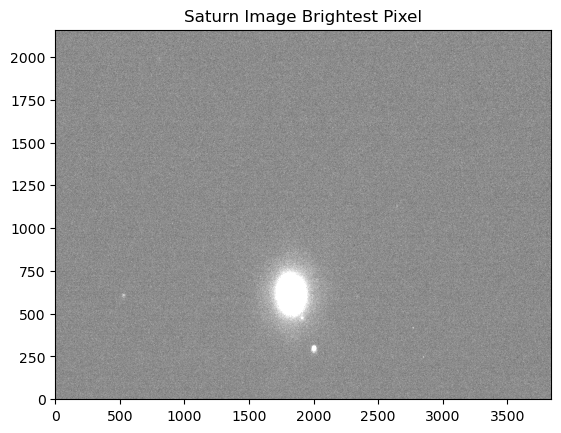

In [6]:
cal_counts = counts - np.median(counts)
plt.imshow(imagedata, cmap = "gray", vmin = np.percentile(imagedata,1.),
          vmax = np.percentile(imagedata, 99.) , origin = "lower", aspect='auto')
plt.title("Saturn Image Brightest Pixel")

plt.plot(briP[1], briP[0], 'o', color = "hotpink", label = "sat center")
plt.plot(3840/2, 2160/2, 'o', color = 'black', label = "image center")
plt.legend()

First, establish the x and y position arrays. 
3840 x 2160 pixels

In [7]:
positionx = np.zeros_like(imagedata, dtype=np.int32)   
print(imagedata.shape)
print(positionx.shape)
j = 0 # start at origin
k = 0
for i in range(int(3840)):
    positionx[:,int(j)] = k
    k+=1
    j+=1
    
positiony = np.zeros_like(imagedata, dtype=np.int32)   
j = 0 # start at origin
k = 0
for i in range(int(2160)):
    positiony[int(j),:] = k
    k+=1
    j+=1

(2160, 3840)
(2160, 3840)


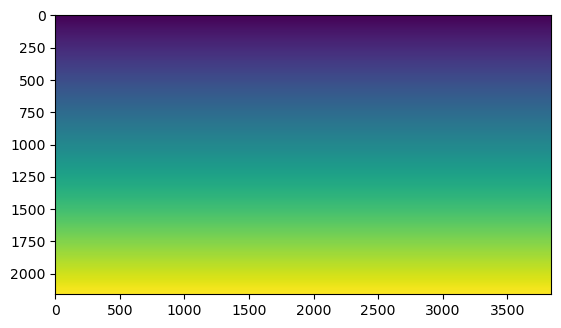

In [8]:
plt.imshow(positiony)

In [ ]:
cal_counts = counts - np.median(counts)
plt.imshow(imagedata, cmap = "gray", vmin = np.percentile(imagedata,1.),
          vmax = np.percentile(imagedata, 99.) , origin = "lower", aspect='auto')
plt.title("Saturn Image Brightest Pixel")

plt.plot(briP[1], briP[0], 'o', color = "hotpink", label = "sat center")
plt.plot(3840/2, 2160/2, 'o', color = 'black', label = "image center")
plt.plot(weight_x, weight_y, 'o', color="orange", label = "ashley")
plt.legend()

In [3]:
brightPix = []



def centroid(images, threshold=250):
    cenX = []
    cenY = []
    for image in images:
        imagedata = fits.getdata(image)
        
        #set all pixels outside object = 0
        mask = imagedata<threshold
        imagedata[mask] = 0

        x_mul = imagedata*positionx
        sum_xmul = np.sum(x_mul)
        weight_x = sum_xmul/(np.sum(imagedata))

        y_mul = imagedata*positiony
        sum_ymul = np.sum(y_mul)
        weight_y = sum_ymul/(np.sum(imagedata))

        cenX.append(weight_x)
        cenY.append(weight_y)
    return cenX, cenY
        
def briPix(images):
    for image in images:
        imagedata = fits.getdata(image)
        
        briP = np.unravel_index(np.argmax(imagedata, axis=None), imagedata.shape)
        brightPix.append(briP)

In [4]:
allimagepath = "/Users/ashleyashiku/Desktop/PULSE-A/operation/*.fits"
imagelog = glob.glob(allimagepath)

# using Rodrigo's code here
def natural_sort_key(filename):
    """
    Extracts the first sequence of digits and converts it to an integer 
    for numerical sorting.
    """
    # Find all sequences of digits in the string
    digits = re.findall(r'\d+', filename)
    if digits:
        # Convert the first found number to an integer
        return int(digits[0])
    return filename # Fallback for files without numbers

# Sort the list using the custom key
filenames=sorted(imagelog,key=natural_sort_key)

In [5]:
def get_file_timestamps(filename):
    folder_path = ""
    modification_time = os.path.getmtime(folder_path+'/'+filename)
    return (modification_time)

In [78]:
print(get_file_timestamps(filenames[1])-get_file_timestamps(filenames[0]))
print(get_file_timestamps(filenames[2])-get_file_timestamps(filenames[1]))
print(get_file_timestamps(filenames[3])-get_file_timestamps(filenames[2]))
print(get_file_timestamps(filenames[6])-get_file_timestamps(filenames[5]))

0.32299184799194336
0.32428574562072754
0.32211732864379883
0.315899133682251


(0.0, 5.0)

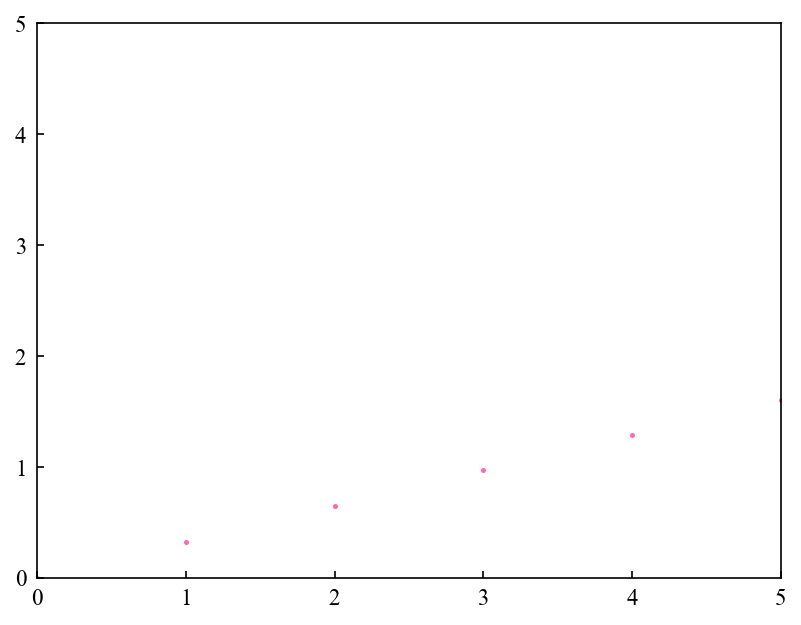

In [86]:
plt.scatter(np.arange(len(timeRel)), timeRel, color = "hotpink", s = 2)
plt.ylim(0,5)
plt.xlim(0,5)

In [88]:
timestamps = []
for image in filenames:
    opT = get_file_timestamps(image)
    timestamps.append(opT)

In [47]:
# make relative time
startT = timestamps[0]
timestamps = np.array(timestamps)
timeRel = timestamps - startT
#print(timeRel)

In [43]:
#print(filenames[0:10])
#print(timestamps)

In [21]:
xCtest, yCtest = centroid(filenames)

In [52]:
# plate scale 
plate_scale=17.9/(47.5*2)

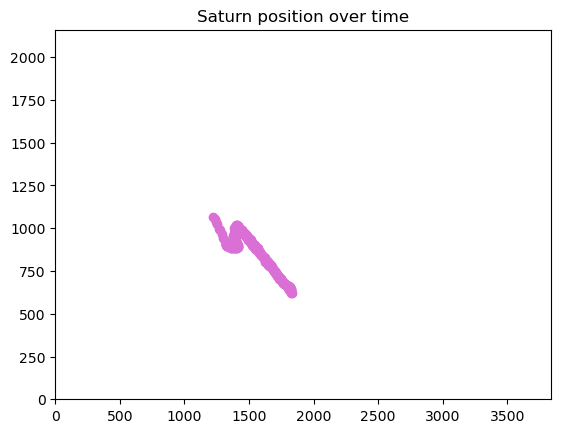

<Figure size 640x480 with 0 Axes>

In [22]:
plt.scatter(xCtest, yCtest, color = "orchid")
plt.ylim(0,2160)
plt.xlim(0,3840)
plt.title("Saturn position over time")
plt.plot
plt.show()
plt.savefig("sat_pos.jpg")

Text(0.5, 1.0, 'Saturn X position over time')

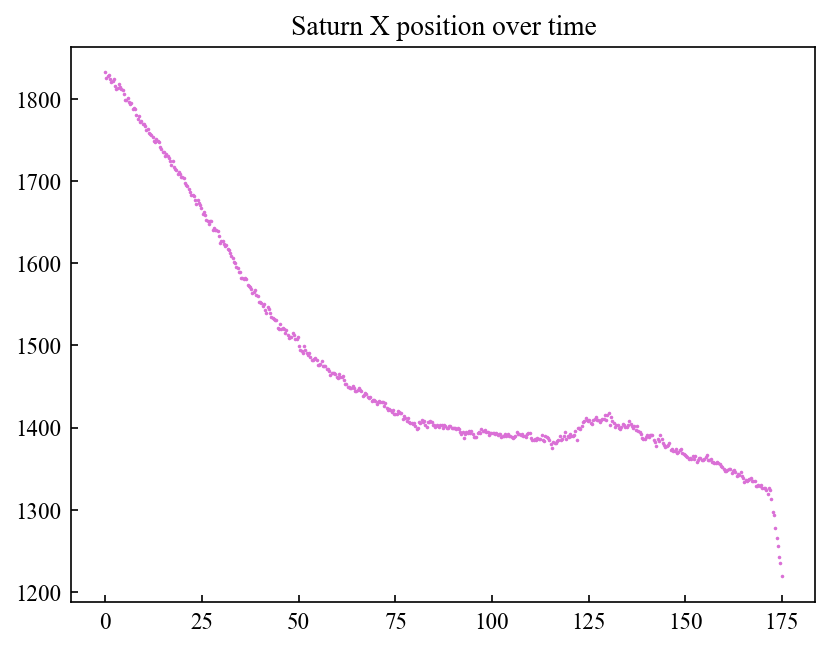

In [89]:
plt.scatter(timeRel, cenX, color = "orchid", s=0.5)
plt.title("Saturn X position over time")

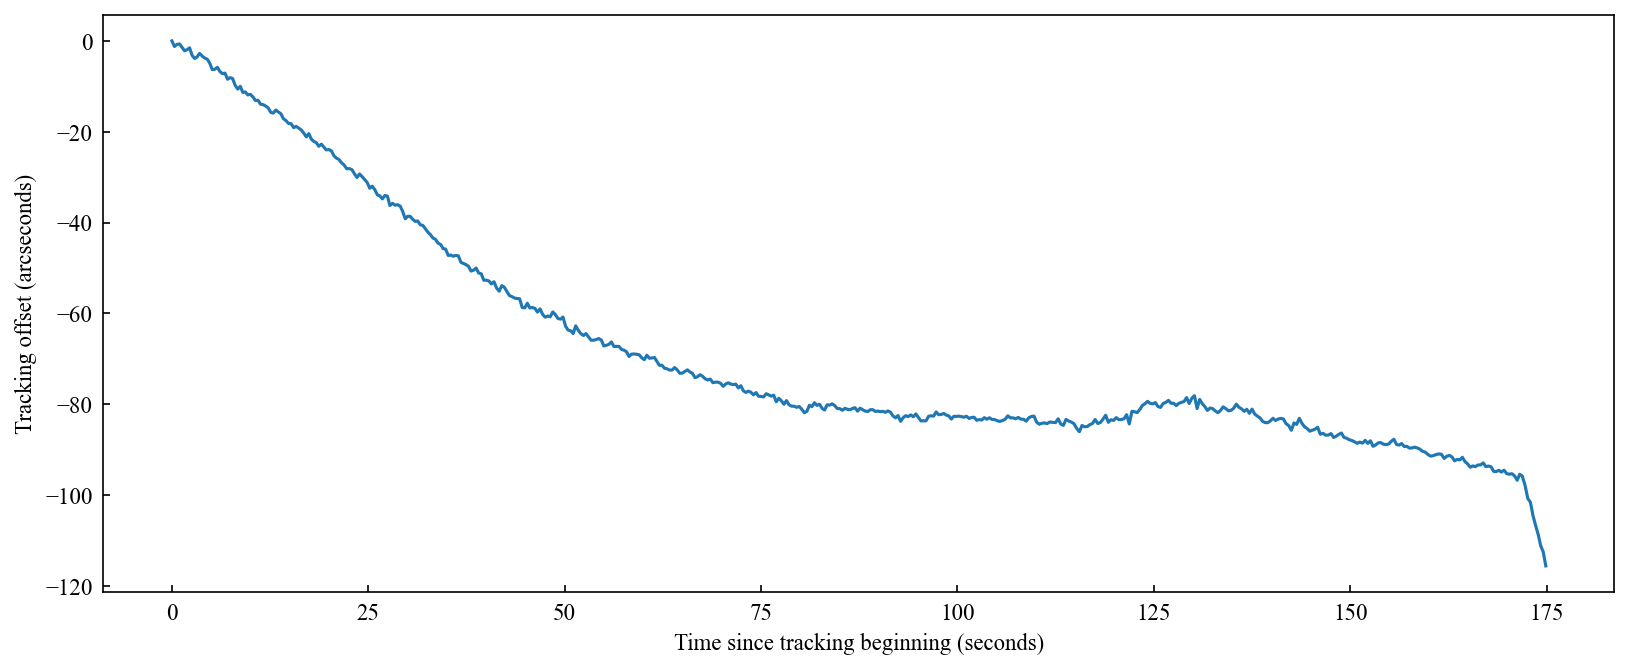

In [62]:
fig, ax = plt.subplots(figsize=(13, 5))   
ax.plot(timeRel, x_resi*plate_scale)  
ax.set_xlabel('Time since tracking beginning (seconds)')
ax.set_ylabel('Tracking offset (arcseconds)')
plt.show() 

In [98]:
org = np.array([1403.98, 890.164])
orgP = np.array([1372.85, 945.656])

org = org.reshape((2,1))
orgP = orgP.reshape((2,1))

#invOrg = np.linalg.inv(org)

print(orgP.shape)

(2, 1)


In [133]:
r1 = np.array([1375.2911 , 950.41966])
r2 = np.array([1433.7599, 841.27788])

# find x and y difference and divide by two to find centerpoint:
centerpoint = r1 + ((r2-r1)/2)

print(centerpoint)

[1404.5255   895.84877]
[ 5.34745000e+01 -1.13686838e-13]


In [131]:
v1 = np.array([1458, 895.84877]) # x axis
v2 = np.array([1433.7599, 841.27788]) # rotated axis (azimuth)
v = np.array(v1-centerpoint)
w = np.array(v2-centerpoint)

def angle(x, y):
    dotpro = np.sum(x*y)
    lenx = np.sqrt(np.sum(x**2))
    leny = np.sqrt(np.sum(y**2))
    
    work = dotpro/(lenx*leny)
    angle_radians = math.acos(work)
    angle_degrees = math.degrees(angle_radians)
    return math.degrees(angle_radians)
    
offsetAngle = angle(v,w)   
print(v)
print(w)

print(offsetAngle)

[ 5.34745000e+01 -1.13686838e-13]
[ 29.2344  -54.57089]
61.82141426042611


In [134]:
angle_rad = math.radians(360-offsetAngle)

rotMat = np.array([[math.cos(angle_rad), -math.sin(angle_rad)], 
                  [math.sin(angle_rad), math.cos(angle_rad)]])

print(rotMat@v)

[ 25.25180033 -47.13670258]


In [147]:
def rotation(angle, x):
    # turn from degrees to radians
    angle_rad = -math.radians(angle)

    rotMat = np.array([[math.cos(angle_rad), -math.sin(angle_rad)], 
                  [math.sin(angle_rad), math.cos(angle_rad)]])
    
    # rotate vector x
    return rotMat@x

tester = rotation(offsetAngle, v)
print(tester[0])

25.25180032808062


Now, let's apply this rotation matrix onto our x and y pixel coordinates.

First, I'm going to zip all the x and y pixels.

In [148]:
cenZip = zip(cenX, cenY)
cenZip = list(cenZip)
cenZip = np.array(cenZip)

cenXrot = []
cenYrot = []

for i in cenZip:
    conv = rotation(offsetAngle, i)
    cenXrot.append(conv[0])
    cenYrot.append(conv[1])
    


Text(0.5, 1.0, 'Saturn X position over time')

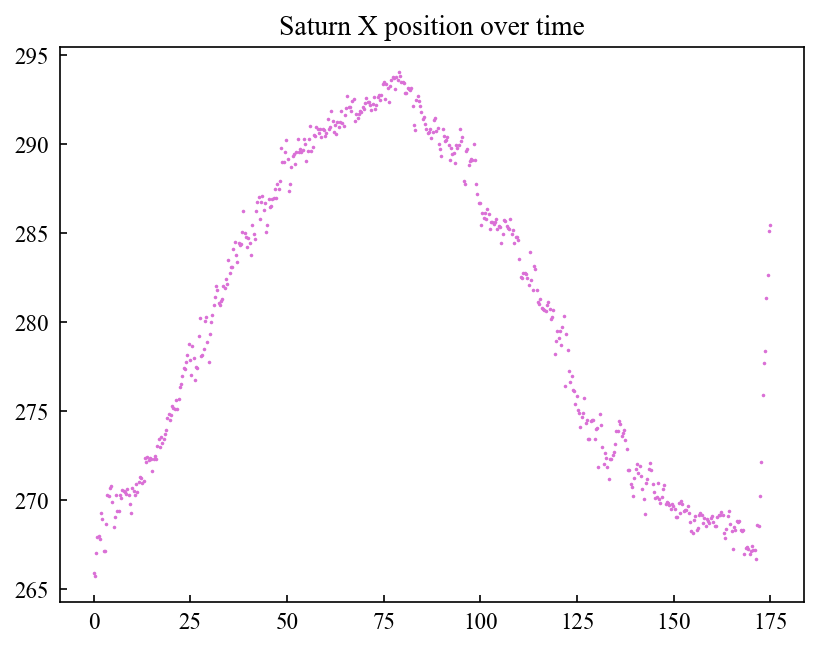

In [155]:
plt.scatter(timeRel, np.array(cenXrot)*plate_scale, color = "orchid", s=0.5)
plt.title("Saturn X position over time")

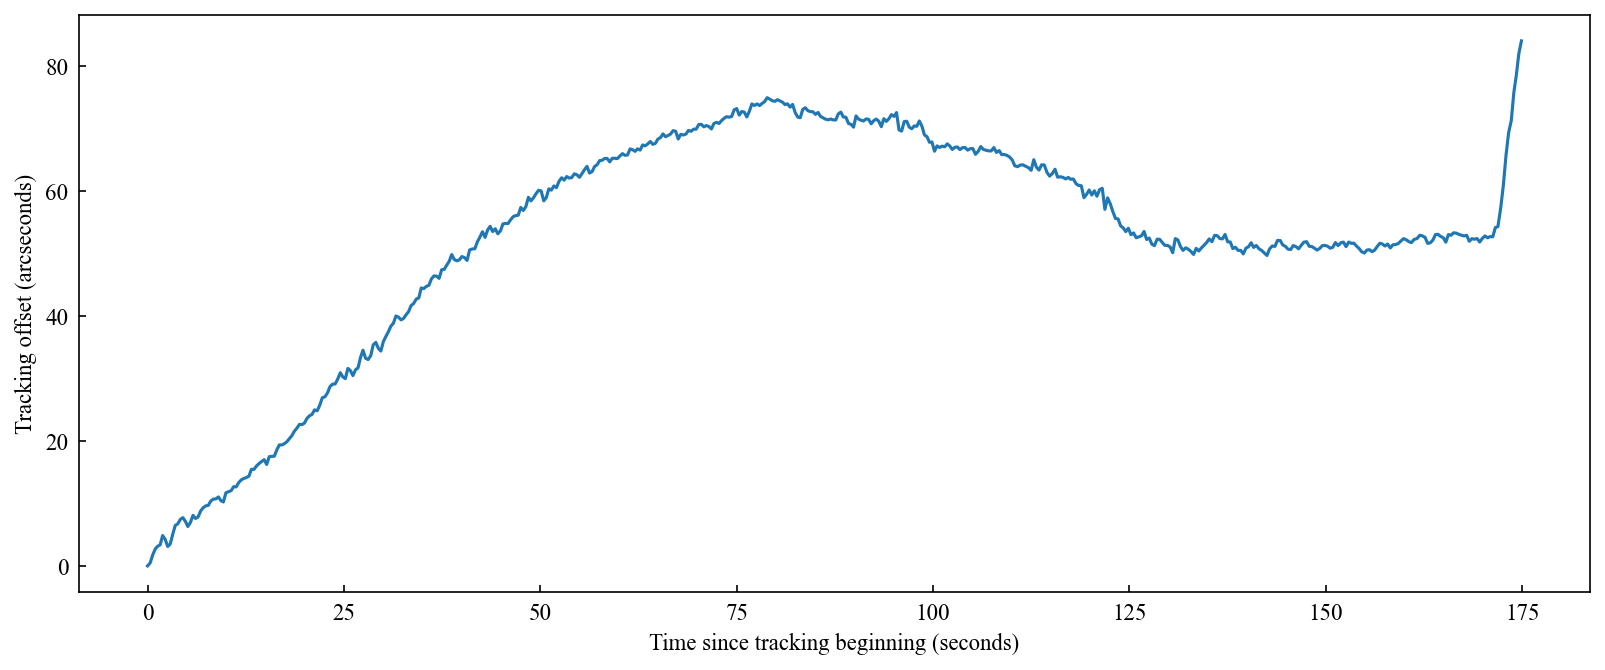

In [63]:
fig, ax = plt.subplots(figsize=(13, 5))   
ax.plot(timeRel, y_resi*plate_scale)  
ax.set_xlabel('Time since tracking beginning (seconds)')
ax.set_ylabel('Tracking offset (arcseconds)')
plt.show() 

In [70]:
# data analysis part
# let's figure out this error

# focusing on x error
print(f"The average x position is {np.mean(cenX)}, the min is {np.min(cenX)}, max {np.max(cenX)}. The std dev {np.std(cenX)}")

print()
print()
print(f"first position is {cenX[0]}")

x_resi = cenX - cenX[0]
y_resi = cenY-cenY[0]


The average x position is 1474.116044086238, the min is 1218.855255313774, max 1832.4032061986297. The std dev 138.11548903261874


first position is 1832.4032061986297


Finding the RMS error:

In [67]:
def rms(data):
    roots = []
    for d in data:
        initial = d[0]
        resi = d - initial
        
        root = np.sqrt(np.mean(resi**2))
        roots.append(root)
    return roots

In [158]:
xRoot, yRoot = rms((cenX, cenY))
print(f"X RMS error: {xRoot*plate_scale:.2f} arcsec")
print(f"Y RMS error: {yRoot*plate_scale:.2f} arcsec")
print("")

azRoot, alRoot = rms((cenXrot, cenYrot))
print(f"Az RMS error: {azRoot*plate_scale:.2f} arcsec")
print(f"Al RMS error: {alRoot*plate_scale:.2f} arcsec")

X RMS error: 72.35 arcsec
Y RMS error: 55.74 arcsec

Az RMS error: 16.92 arcsec
Al RMS error: 89.75 arcsec


Let's try and make sense of this by plotting over the image.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


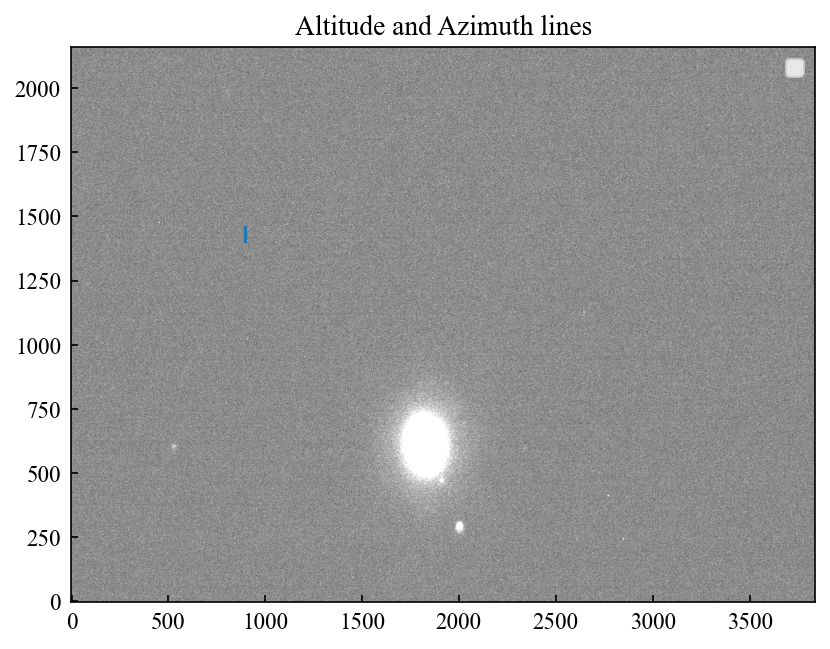

In [163]:
plt.imshow(imagedata, cmap = "gray", vmin = np.percentile(imagedata,1.),
          vmax = np.percentile(imagedata, 99.) , origin = "lower", aspect='auto')
plt.title("Altitude and Azimuth lines")
plt.plot((v1[1], centerpoint[1]), (v1[0], centerpoint[0]) )
plt.legend()

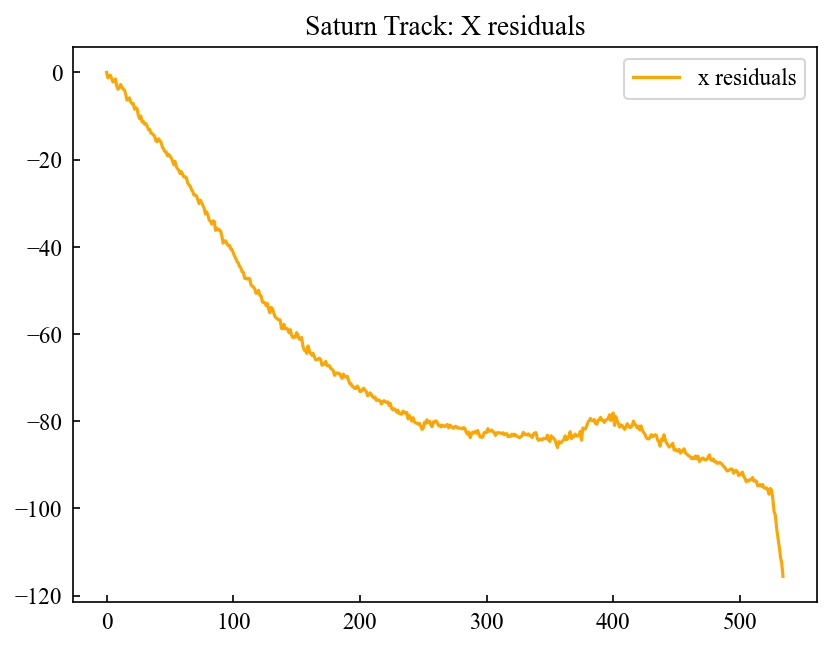

In [66]:
plt.plot(x_resi*plate_scale, color = "orange", label = "x residuals")
plt.title("Saturn Track: X residuals")
#plt.ylim(-3840/2,3840/2)
plt.legend()

In [ ]:
plt.plot(y_resi, color = "yellow", label = "x residuals")
plt.title("Saturn Track: Y residuals")
plt.ylim(-2160/2,2160/2)
plt.legend()

In [ ]:
plt.scatter(x_resi, y_resi, color = "hotpink")

In [ ]:
plt.scatter(np.arange(len(ycen)), ycen, color = "lightpink", label = "x position")


In [ ]:
# find root-mean-squared error for x and y
rmsX = (np.mean(x_resi**2))

In [ ]:
briPix(imagelog)


In [ ]:
bripixX = []
bripixY = []
for i in range(len(brightPix)):
    x = brightPix[i][0]
    y = brightPix[i][1]
    
    bripixX.append(x)
    bripixY.append(y)

In [ ]:
plt.scatter(bripixX, bripixY, color = "hotpink")
plt.xlim(0,3840)
plt.ylim(0,2160)

In [50]:
# here, i am importing Professor Andrey Kravtsov's code for my plots. It makes them visually appealing!
# import relevant packages

import matplotlib.pyplot as plt
import numpy as np 

# the following commands make plots look better
def plot_prettier(dpi=150, fontsize=11, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
        

plot_prettier(dpi=150, fontsize=11)

In [ ]:
import time

In [ ]:
print(time.time())